# Cell Hashing and Sample Demultiplexing

This notebook covers the step that comes *before* single-cell analysis: sample multiplexing and demultiplexing using cell hashing.

At every stage we ask:
- What is happening biologically or technically?
- Why does this step matter?
- What should I see in the output?


---
## 1. What Is Cell Hashing?

Cell hashing (Stoeckius et al. 2018, *Nature Methods*) is a way to run multiple biological samples through a single sequencing lane.

**The idea.** Before pooling, each sample is labeled with a unique antibody-conjugated DNA barcode called a Hashtag Oligo (HTO). HTOs bind non-specifically to the surface of all cells. After pooling and sequencing you can assign each cell back to its original sample by identifying which HTO it carries.

**Why it matters:**
- **Cost** — one sequencing run replaces N runs, reducing per-sample cost proportionally
- **Batch effects** — all samples are processed in the same lane, eliminating inter-run technical variation (the problem Notebook 2 addresses after the fact)
- **Doublet detection** — two cells from *different* samples that land in the same droplet carry two distinct HTOs, a signal that is otherwise invisible

**The data you get:**
- A standard RNA count matrix (cells × genes) — identical in format to any scRNA-seq run
- An HTO count matrix (cells × hashtags) — the key to recovering sample identity

**What this notebook does:**
1. Load real RNA and HTO count matrices from a published hashing experiment
2. Apply quality control
3. Use a Gaussian Mixture Model (GMM) to classify each cell as a singlet, doublet, or negative
4. Split the data into per-sample AnnData objects ready for Notebook 1's QC-to-clustering pipeline


---
## A note on upstream processing

This notebook starts from count matrices. The step that produces them — aligning raw FASTQ reads to the genome and quantifying UMI counts — is handled by tools like:

- **CellRanger** (10x Genomics platform)
- **PIPseeker** (Fluidigm/Curio platform)
- **STARsolo** (open-source alternative)

If your lab uses PIPseeker, its output directory will contain a gene expression matrix and, if you sequenced a hashing library, an HTO count matrix. The loading steps below apply directly to that output.


---
## 2. Setup


In [1]:
import os
import gzip
import urllib.request

import numpy as np
import pandas as pd
import scipy.sparse
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import seaborn as sns
import scanpy as sc
from sklearn.mixture import GaussianMixture

sc.settings.verbosity = 1
sc.set_figure_params(dpi=80)
np.random.seed(42)

---
## 3. Dataset: Stoeckius et al. 2018

We use data from the original cell hashing paper (GEO accession GSE108313). Eight PBMC samples from eight healthy donors were labeled with eight HTOs and sequenced together on a 10x Genomics platform. This is the canonical reference dataset for cell hashing methodology.

We download two files:
- **HTO counts** (`GSM2895283_Hashtag-HTO-count.csv.gz`, ~1 MB) — hashtag antibody UMI counts
- **RNA counts** (`GSM2895282_Hashtag-RNA.umi.txt.gz`, ~33 MB) — gene expression UMI counts

Both files use a dense row-per-feature layout — not the sparse `.mtx` format that 10x CellRanger produces. Loading them requires a pandas round-trip before creating AnnData.

Files are cached after the first download so re-running the notebook is fast. The RNA file is large; we subset to 5,000 cells to keep memory and runtime manageable while preserving all the patterns the demultiplexing analysis depends on. The first run saves the subset to cache; subsequent runs load in seconds.


In [2]:
CACHE_DIR = os.path.expanduser("~/.cache/scrna_notebooks")
os.makedirs(CACHE_DIR, exist_ok=True)

# Each file lives under its own sample-level GEO FTP path
GEO_URLS = {
    "GSM2895283_Hashtag-HTO-count.csv.gz":
        "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM2895nnn/GSM2895283/suppl/GSM2895283_Hashtag-HTO-count.csv.gz",
    "GSM2895282_Hashtag-RNA.umi.txt.gz":
        "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM2895nnn/GSM2895282/suppl/GSM2895282_Hashtag-RNA.umi.txt.gz",
}

def download_if_needed(filename):
    path = os.path.join(CACHE_DIR, filename)
    if not os.path.exists(path):
        print(f"Downloading {filename} ...")
        urllib.request.urlretrieve(GEO_URLS[filename], path)
        print("  done.")
    else:
        print(f"  {filename}: using cached copy")
    return path

hto_path = download_if_needed("GSM2895283_Hashtag-HTO-count.csv.gz")
rna_path = download_if_needed("GSM2895282_Hashtag-RNA.umi.txt.gz")

  done.
  done.


---
## 4. Load Data

### Inspecting file formats

Before loading we peek at the first few lines of each file to confirm the layout. This is good practice whenever working with files from a public repository — format conventions vary between labs and platforms.


In [3]:
print("=== HTO file: first 3 rows, first 6 fields ===")
with gzip.open(hto_path, 'rt') as f:
    for i, line in enumerate(f):
        fields = line.strip().split(',')
        print(fields[:6])
        if i == 2:
            break

print()
print("=== RNA file: first 3 rows, first 5 fields ===")
with gzip.open(rna_path, 'rt') as f:
    for i, line in enumerate(f):
        fields = line.strip().split('\t')
        print(fields[:5])
        if i == 2:
            break

=== HTO file: first 3 rows, first 6 fields ===
['', 'GGCGACTAGAGGACGG', 'CATCAAGGTCTTGTCC', 'AAACCTGAGTGATCGG', 'TGAGGGAGTACTTAGC', 'CCTAAAGAGATGTGGC']
['BatchA-AGGACCATCCAA', '30', '4', '12', '26', '7']
['BatchB-ACATGTTACCGT', '16', '39', '15', '20', '4']

=== RNA file: first 3 rows, first 5 fields ===
['GENE', 'CAACCAACACCGCTAG', 'TGCCAAATCTCTAAGG', 'ACTGCTCAGGTGTTAA', 'TTCTTAGTCAACACGT']
['0610007N19Rik', '0', '0', '0', '0']
['0610007P14Rik', '0', '0', '1', '0']


The HTO file is a CSV with **8 rows** (one per hashtag) and one column per cell barcode. The RNA file is a tab-separated matrix with **genes as rows** and cell barcodes as columns. Both need to be transposed so that rows represent cells — the standard AnnData orientation.

### Loading strategy

We load HTO in full (only ~1 MB compressed). For RNA we read the header to identify shared barcodes, randomly select 5,000, then use pandas `usecols` to read only those columns — avoiding loading the full ~35,000-cell matrix into memory.

A cached `.h5ad` is written after the first load so that re-runs skip this step entirely.


In [4]:
SUBSET_CACHE = os.path.join(CACHE_DIR, "hashing_subset_5k.h5ad")

# ── Load HTO ──────────────────────────────────────────────────────────────────
hto_df = pd.read_csv(hto_path, index_col=0, compression='gzip')
hto_df = hto_df.T          # → cells × HTOs
hto_names = list(hto_df.columns)

print(f"HTO matrix: {hto_df.shape[0]:,} cells × {len(hto_names)} hashtags")
print(f"Hashtags: {hto_names}")
print()


HTO matrix: 65,000 cells × 11 hashtags
Hashtags: ['BatchA-AGGACCATCCAA', 'BatchB-ACATGTTACCGT', 'BatchC-AGCTTACTATCC', 'BatchD-TCGATAATGCGA', 'BatchE-GAGGCTGAGCTA', 'BatchF-GTGTGACGTATT', 'BatchG-ACTGTCTAACGG', 'BatchH-TATCACATCGGT', 'bad_struct', 'no_match', 'total_reads']



In [5]:
# ── Load RNA + build AnnData ──────────────────────────────────────────────────
if os.path.exists(SUBSET_CACHE):
    adata = sc.read_h5ad(SUBSET_CACHE)
    hto_names = adata.uns['HTO_names']
    print(f"Loaded 5,000-cell subset from cache.")
else:
    # Read RNA header to enumerate all cell barcodes
    with gzip.open(rna_path, 'rt') as f:
        header = f.readline().strip().split('\t')
    all_rna_cells = header[1:]    # header[0] is the gene-name column

    # Intersect with HTO barcodes
    hto_cells = set(hto_df.index)
    shared = [c for c in all_rna_cells if c in hto_cells]
    print(f"Cells in RNA: {len(all_rna_cells):,}")
    print(f"Cells in HTO: {len(hto_df):,}")
    print(f"Shared:       {len(shared):,}")

    # Subset to 5,000 cells
    selected = list(np.random.choice(shared, size=min(5000, len(shared)), replace=False))
    selected_set = set(selected)

    # Read only the columns we need, identified by position
    col_positions = [0] + [i for i, c in enumerate(header) if c in selected_set]
    print(f"\nReading RNA for {len(selected):,} cells")
    print("(Parsing the full file to extract selected columns — takes ~1 min.)")
    rna_df = pd.read_csv(rna_path, sep='\t', compression='gzip',
                         usecols=col_positions, header=0)
    rna_df = rna_df.set_index(rna_df.columns[0]).T   # → cells × genes
    print("Done.")

    # Create AnnData; store expression as sparse matrix
    adata = sc.AnnData(
        X=scipy.sparse.csr_matrix(rna_df.values.astype(np.float32)),
        obs=pd.DataFrame(index=rna_df.index),
        var=pd.DataFrame(index=rna_df.columns)
    )

    # Attach HTO counts for matching cells
    adata.obsm['HTO_counts'] = hto_df.loc[adata.obs_names].values.astype(np.float32)
    adata.uns['HTO_names']   = hto_names

    adata.write_h5ad(SUBSET_CACHE)
    print("Subset saved to cache.")

print()
print(adata)

Cells in RNA: 50,000
Cells in HTO: 65,000
Shared:       39,842

Reading RNA for 5,000 cells
(Parsing the full file to extract selected columns — takes ~1 min.)
Done.
Subset saved to cache.

AnnData object with n_obs × n_vars = 5000 × 40899
    uns: 'HTO_names'
    obsm: 'HTO_counts'


---
## 5. Quality Control

We apply two rounds of QC:

1. **RNA QC** — the same metrics as Notebook 1 (gene count, UMI count, MT fraction). Low gene counts indicate empty droplets; high MT fraction indicates damaged cells.

2. **HTO QC** — cells with very low total HTO counts failed to capture any hashtag signal and cannot be reliably assigned to a sample. We flag and remove them.

**Pre-demultiplexing thresholds are deliberately permissive.** We are working with pooled samples of unknown composition. Strict per-sample thresholds (e.g., a tight MT cutoff tuned for one donor) are better applied *after* splitting, when you know which cells belong to which sample. Here we only remove clear failures.


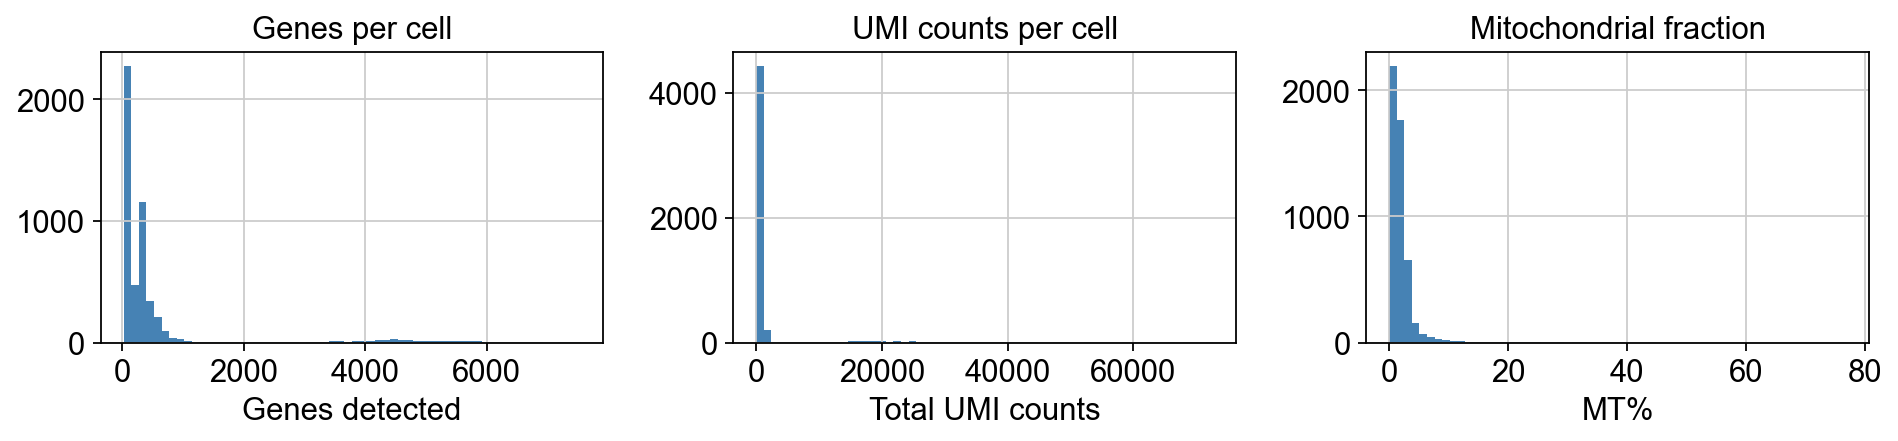

In [6]:
# RNA QC metrics
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].hist(adata.obs['n_genes_by_counts'], bins=60, color='steelblue', edgecolor='none')
axes[0].set_xlabel('Genes detected'); axes[0].set_title('Genes per cell')

axes[1].hist(adata.obs['total_counts'], bins=60, color='steelblue', edgecolor='none')
axes[1].set_xlabel('Total UMI counts'); axes[1].set_title('UMI counts per cell')

axes[2].hist(adata.obs['pct_counts_mt'], bins=60, color='steelblue', edgecolor='none')
axes[2].set_xlabel('MT%'); axes[2].set_title('Mitochondrial fraction')

plt.tight_layout()
plt.show()

### HTO QC

Each cell should carry some detectable hashtag signal. Cells with a very low total HTO count likely failed to label during sample prep and will produce unreliable demultiplexing calls. The histogram below should show a sharp peak of well-labeled cells and a low-count tail of failures.


/var/folders/2f/bl3gx3l16fzcbmxhlpqqxr8c0000gn/T/ipykernel_6404/2977793758.py:11: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/2f/bl3gx3l16fzcbmxhlpqqxr8c0000gn/T/ipykernel_6404/2977793758.py:11: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/gavinoliver/git_repos/scrna-basics/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/gavinoliver/git_repos/scrna-basics/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


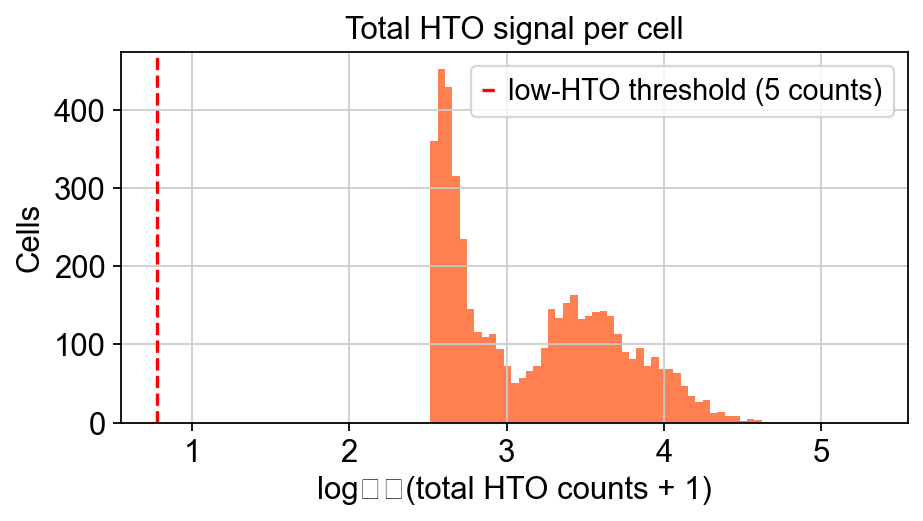

Cells with total HTO count < 5: 0


In [7]:
hto_total = adata.obsm['HTO_counts'].sum(axis=1)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(np.log10(hto_total + 1), bins=60, color='coral', edgecolor='none')
ax.axvline(np.log10(6), color='red', linestyle='--', linewidth=1.5,
           label='low-HTO threshold (5 counts)')
ax.set_xlabel('log₁₀(total HTO counts + 1)')
ax.set_ylabel('Cells')
ax.set_title('Total HTO signal per cell')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Cells with total HTO count < 5: {(hto_total < 5).sum():,}")

In [8]:
pre_filter = adata.n_obs
keep = (
    (adata.obs['n_genes_by_counts']  > 200)  &
    (adata.obs['pct_counts_mt']      < 20)   &    # permissive pre-demux threshold
    (adata.obsm['HTO_counts'].sum(axis=1) >= 5)   # must have detectable HTO signal
)
adata = adata[keep].copy()
print(f"Cells before filtering: {pre_filter:,}")
print(f"Cells after filtering:  {adata.n_obs:,}")

Cells before filtering: 5,000
Cells after filtering:  2,587


---
## 6. HTO Normalization: Centered Log-Ratio (CLR) Transform

Raw HTO counts vary across cells for two reasons:
1. **True biology** — a cell is positive for one HTO and negative for the others
2. **Technical noise** — total HTO capture efficiency varies across droplets (analogous to sequencing depth in RNA)

The CLR transform removes the depth effect while preserving the positive/negative contrast. For each cell we compute:

```
CLR(x) = log(x + 1) − mean(log(x + 1))   across all HTOs in that cell
```

After CLR, a positive HTO has a strongly positive value and the remaining HTOs have negative values. The result should look clearly bimodal for each hashtag — a cluster of negative cells and a smaller cluster of positive cells — which is exactly what GMM demultiplexing needs to fit.


In [9]:
def clr_transform(counts):
    # Centered log-ratio transform across HTO features, per cell.
    log_x = np.log1p(counts)
    return log_x - log_x.mean(axis=1, keepdims=True)

hto_clr = clr_transform(adata.obsm['HTO_counts'])
adata.obsm['HTO_clr'] = hto_clr

---
## 7. HTO Count Distributions

Visualizing each hashtag's distribution before and after CLR normalization confirms that the transform is working as expected.

**What to look for:**
- **Raw (top row):** skewed, hard to separate positive from negative cells
- **CLR (bottom row):** each distribution should show a clear bimodal shape — a large low peak (negative cells) and a smaller high peak (positive cells). If a hashtag lacks the high-count peak, that sample may be poorly represented or absent.


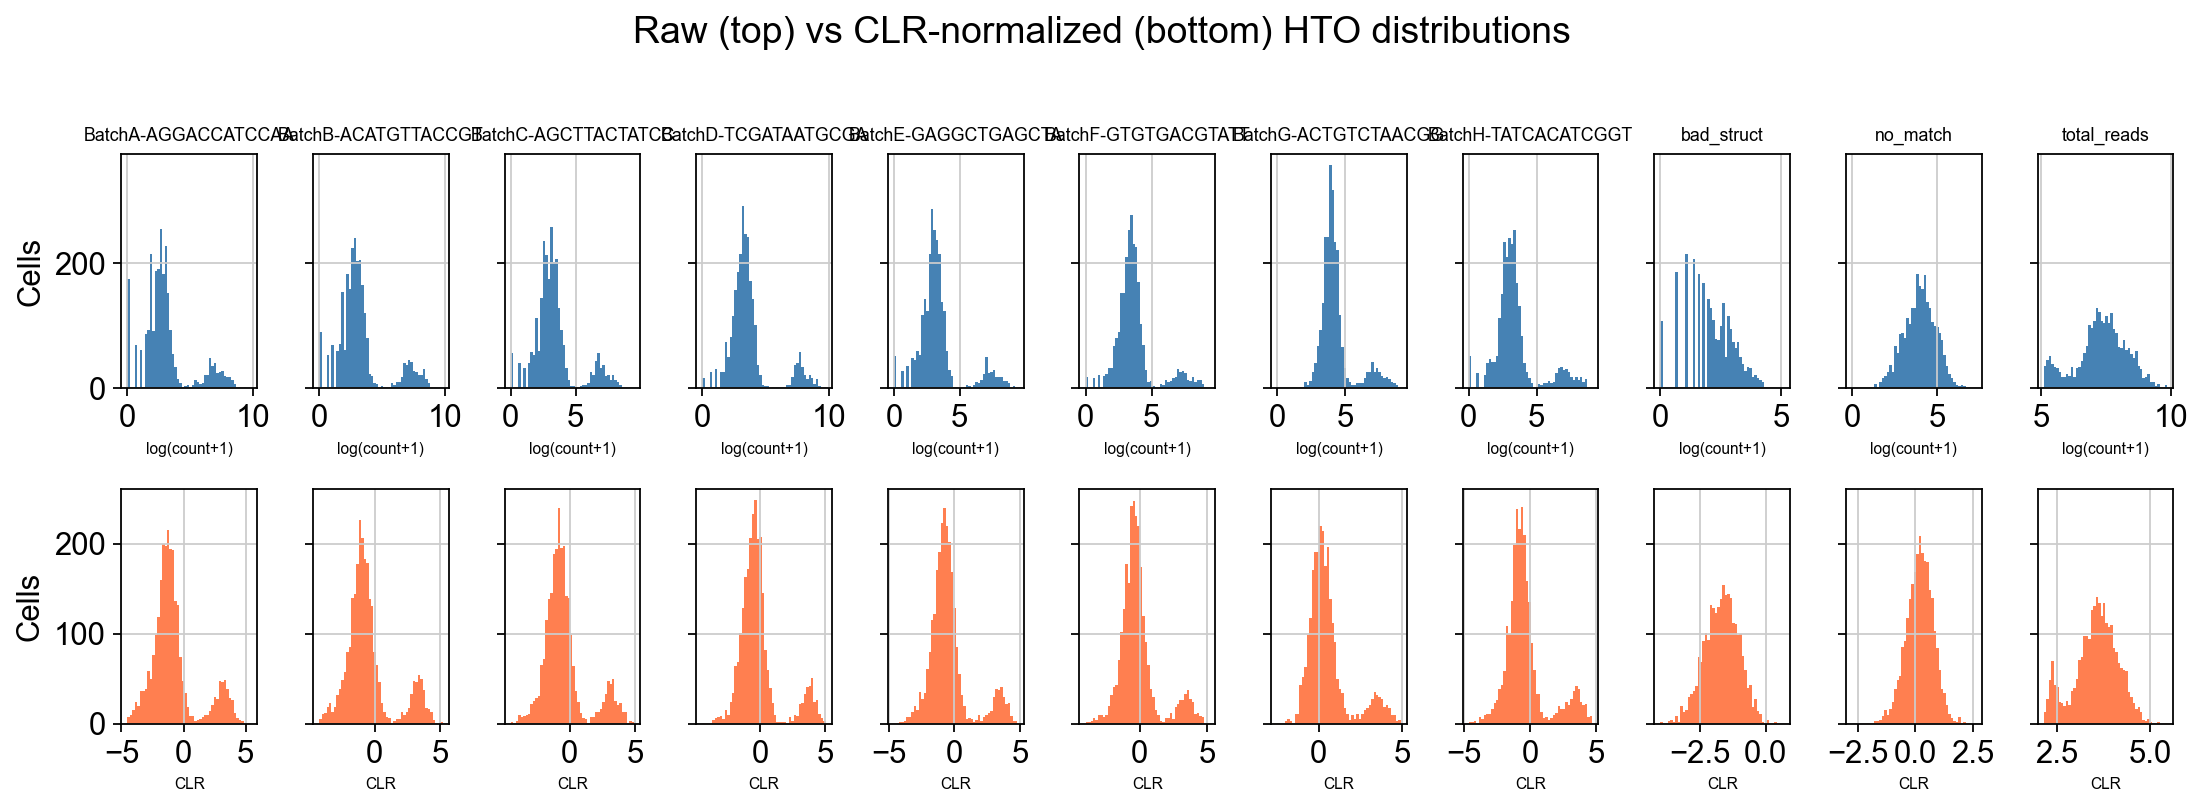

In [10]:
fig, axes = plt.subplots(2, len(hto_names), figsize=(14, 5), sharey='row')
fig.suptitle('Raw (top) vs CLR-normalized (bottom) HTO distributions', y=1.01)

for i, name in enumerate(hto_names):
    axes[0, i].hist(np.log1p(adata.obsm['HTO_counts'][:, i]),
                    bins=50, color='steelblue', edgecolor='none')
    axes[0, i].set_title(name, fontsize=8)
    axes[0, i].set_xlabel('log(count+1)', fontsize=7)

    axes[1, i].hist(hto_clr[:, i], bins=50, color='coral', edgecolor='none')
    axes[1, i].set_xlabel('CLR', fontsize=7)

axes[0, 0].set_ylabel('Cells')
axes[1, 0].set_ylabel('Cells')
plt.tight_layout()
plt.show()

---
## 8. GMM Demultiplexing

For each hashtag we fit a **two-component Gaussian Mixture Model** to the CLR distribution across all cells. The two components correspond to:
- **Negative component** (lower mean) — cells from other samples that received ambient or non-specific HTO signal
- **Positive component** (higher mean) — cells from the sample labeled with this HTO

The model assigns each cell a probability of belonging to the positive component. We then use a 0.5 threshold to make a binary call: positive or negative for each HTO.

GMM is the same approach used by HashSolo (Bernstein et al. 2020) and is similar to the strategy in Seurat's `HTODemux`. It works well when the bimodal separation is clear; for datasets with poor labeling efficiency or very unbalanced sample sizes, more sophisticated methods may be needed.


In [11]:
n_cells = hto_clr.shape[0]
positive_probs = np.zeros((n_cells, len(hto_names)))
gmm_models = {}

for i, name in enumerate(hto_names):
    x = hto_clr[:, i].reshape(-1, 1)
    gmm = GaussianMixture(n_components=2, random_state=42, n_init=10)
    gmm.fit(x)

    # Identify which component has the higher mean — that is the positive (HTO+) component
    pos_idx = int(np.argmax(gmm.means_.flatten()))
    probs = gmm.predict_proba(x)
    positive_probs[:, i] = probs[:, pos_idx]
    gmm_models[name] = (gmm, pos_idx)

print(f"Fitted {len(hto_names)} GMMs.")

Fitted 11 GMMs.


### Visualizing a GMM fit

The plot below shows the CLR distribution for one hashtag with the two fitted Gaussian components overlaid. The negative component (blue) should be tall and narrow — most cells are from other samples. The positive component (red) represents the ~12% of cells from the corresponding donor.

A clean fit with well-separated peaks means reliable demultiplexing. Overlapping components increase doublet and ambiguous calls.


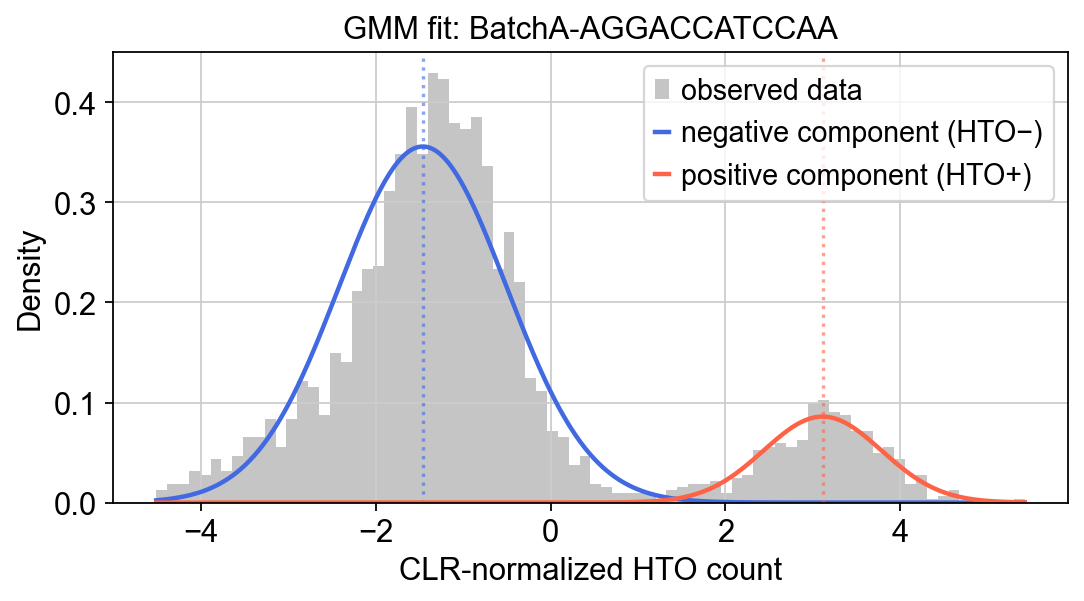

In [12]:
from scipy.stats import norm

name = hto_names[0]
gmm, pos_idx = gmm_models[name]
x_data = hto_clr[:, 0]
x_range = np.linspace(x_data.min(), x_data.max(), 400)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(x_data, bins=80, density=True, alpha=0.45, color='gray', label='observed data')

component_labels = {pos_idx: 'positive component (HTO+)',
                    1 - pos_idx: 'negative component (HTO−)'}
component_colors = {pos_idx: 'tomato', 1 - pos_idx: 'royalblue'}

for comp in range(2):
    mean  = gmm.means_[comp, 0]
    std   = np.sqrt(gmm.covariances_[comp, 0, 0])
    w     = gmm.weights_[comp]
    density = w * norm.pdf(x_range, mean, std)
    ax.plot(x_range, density, lw=2,
            color=component_colors[comp], label=component_labels[comp])
    ax.axvline(mean, color=component_colors[comp], linestyle=':', alpha=0.6)

ax.set_xlabel('CLR-normalized HTO count')
ax.set_ylabel('Density')
ax.set_title(f'GMM fit: {name}')
ax.legend()
plt.tight_layout()
plt.show()

---
## 9. Classify Cells

Using the per-HTO positive probability (threshold = 0.5) we count how many HTOs each cell is positive for and assign a label:

| Positive HTOs | Label | Interpretation |
|---|---|---|
| Exactly 1 | **Singlet** | Cell from a single known donor |
| 2 or more | **Doublet** | Two cells from different donors in one droplet |
| 0 | **Negative** | No detectable hashtag — failed capture or ambient RNA |

Only singlets are used for downstream biological analysis. Doublets and negatives are removed.


In [13]:
threshold = 0.5
pos_calls = positive_probs > threshold      # cells × HTOs boolean matrix
n_positive = pos_calls.sum(axis=1)

assignments    = []
classifications = []

for i in range(n_cells):
    n = n_positive[i]
    if n == 0:
        assignments.append('Negative')
        classifications.append('Negative')
    elif n == 1:
        hto_idx = int(np.where(pos_calls[i])[0][0])
        assignments.append(hto_names[hto_idx])
        classifications.append('Singlet')
    else:
        assignments.append('Doublet')
        classifications.append('Doublet')

adata.obs['HTO_assignment']    = assignments
adata.obs['HTO_classification'] = classifications

Classification summary
────────────────────────────────
  Doublet       2,163   (83.6%)
  Singlet         271   (10.5%)
  Negative        153   (5.9%)
  Total         2,587


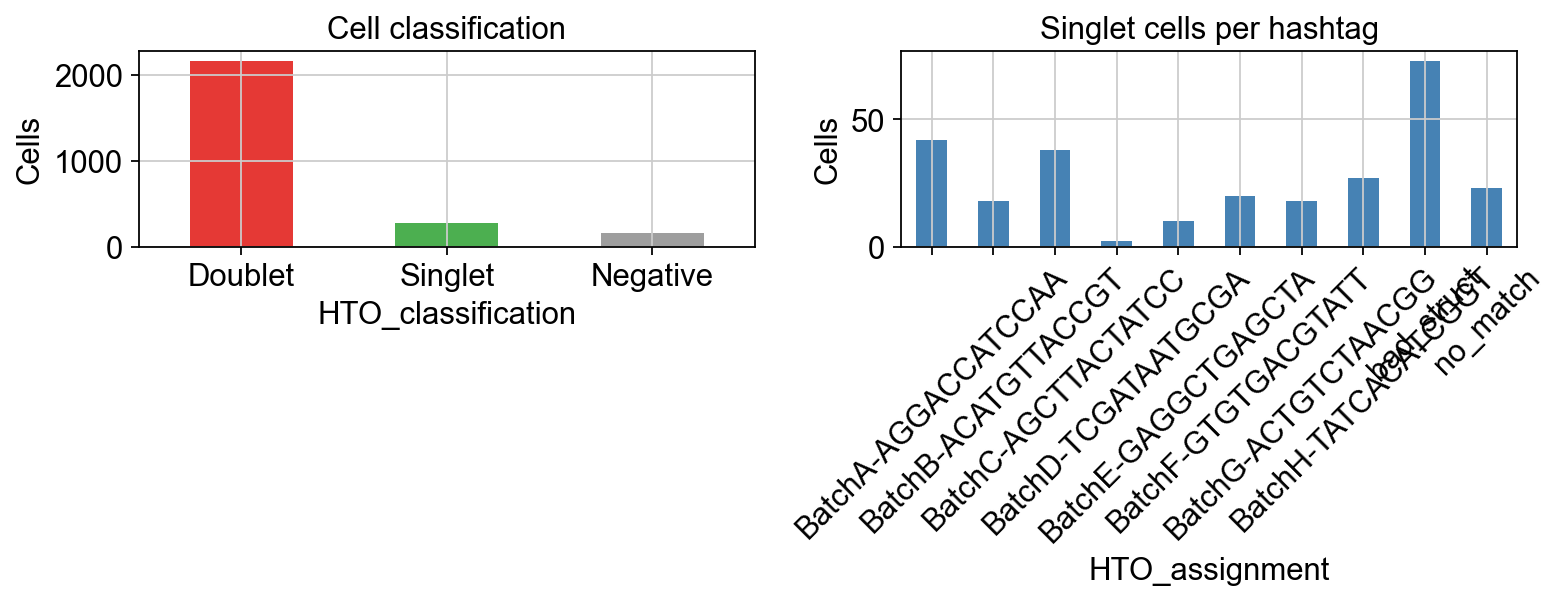

In [14]:
counts = adata.obs['HTO_classification'].value_counts()
total  = counts.sum()

print("Classification summary")
print("─" * 32)
for label, n in counts.items():
    print(f"  {label:<12} {n:>6,}   ({n / total * 100:.1f}%)")
print(f"  {'Total':<12} {total:>6,}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Classification breakdown
bar_colors = {'Singlet': '#4CAF50', 'Doublet': '#E53935', 'Negative': '#9E9E9E'}
counts.plot.bar(ax=axes[0],
                color=[bar_colors.get(c, 'gray') for c in counts.index],
                edgecolor='none')
axes[0].set_title('Cell classification')
axes[0].set_ylabel('Cells')
axes[0].set_xticklabels(counts.index, rotation=0)

# Singlets per hashtag
singlet_mask   = adata.obs['HTO_classification'] == 'Singlet'
singlet_counts = adata.obs.loc[singlet_mask, 'HTO_assignment'].value_counts().sort_index()
singlet_counts.plot.bar(ax=axes[1], color='steelblue', edgecolor='none')
axes[1].set_title('Singlet cells per hashtag')
axes[1].set_ylabel('Cells')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### HTO assignment heatmap

The heatmap below shows CLR values for a sample of cells, grouped by their assignment. Each row is a cell; each column is a hashtag.

**What to look for:**
- Singlet rows should have one bright red column (positive HTO) and blue elsewhere
- Doublet rows should have two red columns
- Negative rows should be uniformly blue or near-zero across all HTOs

A clean demultiplexing result looks like a block-diagonal pattern in this view.


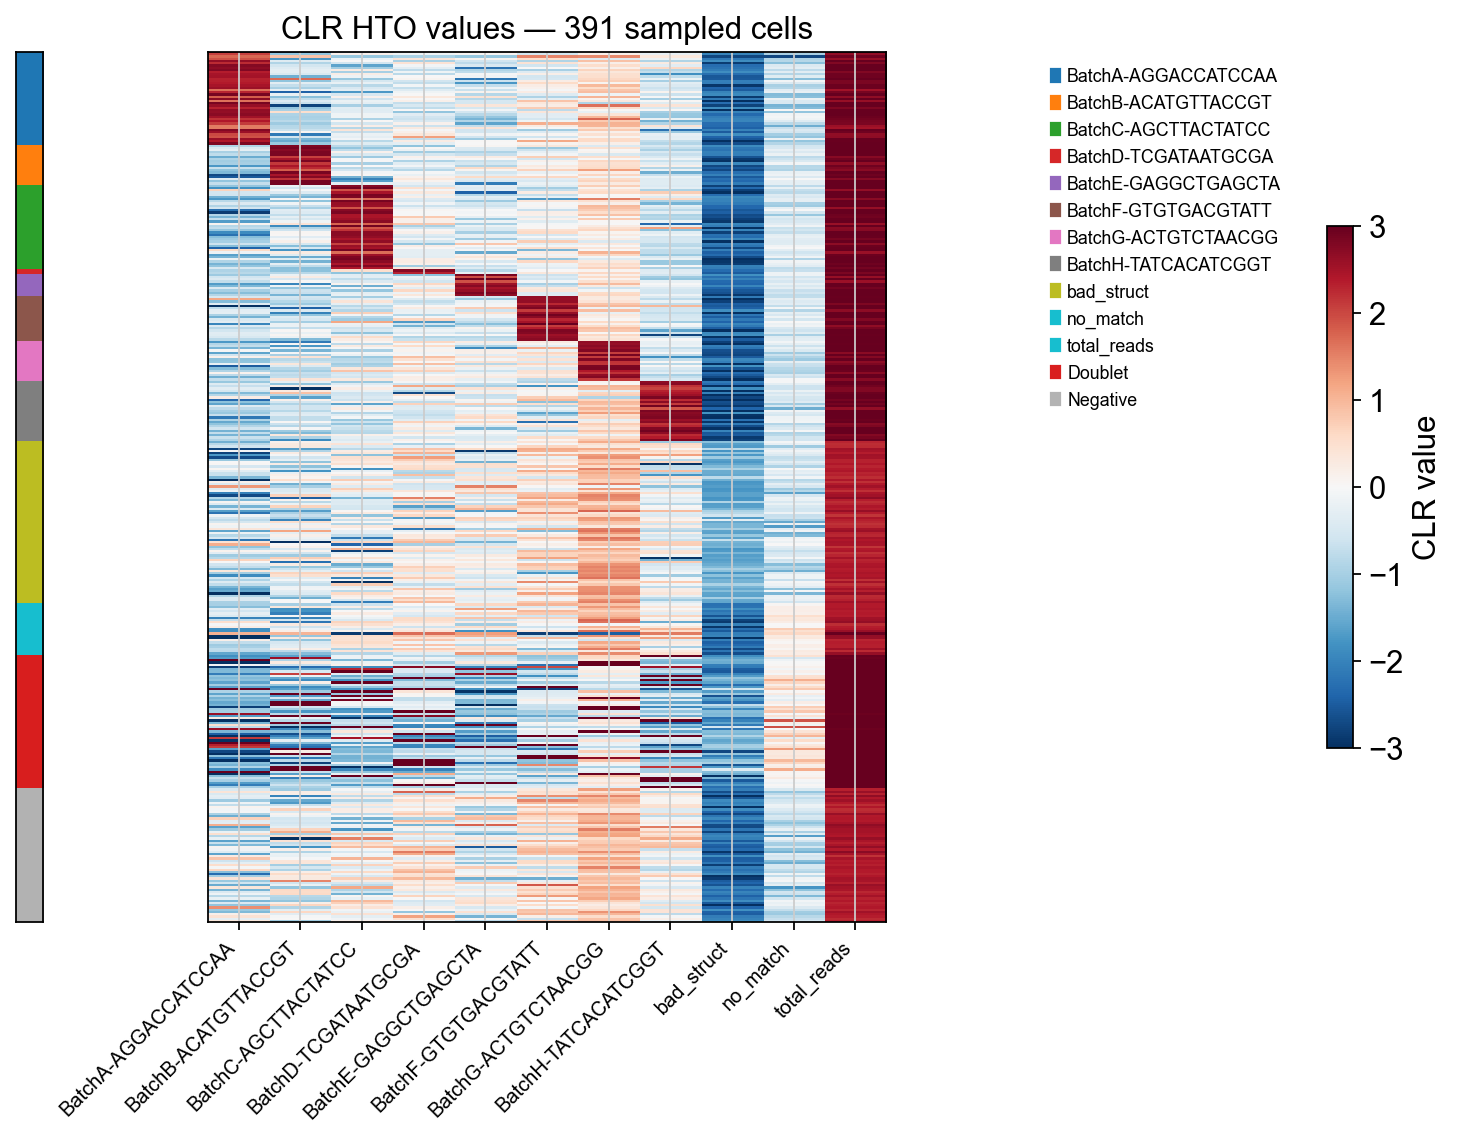

In [15]:
# Sample cells for visualization
n_per_hto  = 100
n_other    = 60
sample_rows, sample_labels = [], []

for hto in hto_names:
    idx = np.where(adata.obs['HTO_assignment'] == hto)[0]
    n   = min(n_per_hto, len(idx))
    chosen = np.random.choice(idx, n, replace=False)
    sample_rows.extend(chosen.tolist())
    sample_labels.extend([hto] * n)

for grp in ['Doublet', 'Negative']:
    idx = np.where(adata.obs['HTO_classification'] == grp)[0]
    n   = min(n_other, len(idx))
    if n > 0:
        chosen = np.random.choice(idx, n, replace=False)
        sample_rows.extend(chosen.tolist())
        sample_labels.extend([grp] * n)

matrix = adata.obsm['HTO_clr'][sample_rows, :]

# Build color sidebar
tab_colors  = [cm.tab10(i / 10) for i in range(len(hto_names))]
group_color = {hto: tab_colors[i] for i, hto in enumerate(hto_names)}
group_color['Doublet']  = (0.85, 0.12, 0.12, 1.0)
group_color['Negative'] = (0.70, 0.70, 0.70, 1.0)
sidebar = np.array([[group_color[l][:3]] for l in sample_labels])

fig, (ax_side, ax_heat) = plt.subplots(
    1, 2, figsize=(9, 7),
    gridspec_kw={'width_ratios': [0.04, 1]},
    constrained_layout=True
)

ax_side.imshow(sidebar, aspect='auto', interpolation='none')
ax_side.set_xticks([])
ax_side.set_yticks([])

im = ax_heat.imshow(matrix, aspect='auto', cmap='RdBu_r',
                    vmin=-3, vmax=3, interpolation='none')
ax_heat.set_xticks(range(len(hto_names)))
ax_heat.set_xticklabels(hto_names, rotation=45, ha='right', fontsize=9)
ax_heat.set_yticks([])
ax_heat.set_title(f'CLR HTO values — {len(sample_rows)} sampled cells')
plt.colorbar(im, ax=ax_heat, label='CLR value', shrink=0.6)

handles = [mpatches.Patch(color=group_color[k], label=k)
           for k in hto_names + ['Doublet', 'Negative']]
ax_heat.legend(handles=handles, bbox_to_anchor=(1.22, 1.0), loc='upper left',
               fontsize=8, frameon=False)
plt.show()

---
## 10. Split Per-Sample

We discard doublets and negatives and split the remaining singlet cells into one AnnData object per donor. Each per-sample object is a self-contained input for the Notebook 1 pipeline.

At this point the RNA counts are still **raw** (not normalized or filtered beyond the broad pre-demux QC above). Per-sample QC — tighter MT thresholds, gene count cutoffs tuned to each sample's distribution — should be applied inside Notebook 1 after loading the appropriate per-sample object.


In [16]:
singlets = adata[adata.obs['HTO_classification'] == 'Singlet'].copy()
print(f"Singlets: {singlets.n_obs:,} of {adata.n_obs:,} cells "
      f"({singlets.n_obs / adata.n_obs * 100:.0f}%)")
print()

per_sample = {}
for hto in hto_names:
    mask = singlets.obs['HTO_assignment'] == hto
    per_sample[hto] = singlets[mask].copy()

print("Per-sample cell counts:")
for hto, sample_adata in per_sample.items():
    print(f"  {hto}: {sample_adata.n_obs:,} cells")

Singlets: 271 of 2,587 cells (10%)

Per-sample cell counts:
  BatchA-AGGACCATCCAA: 42 cells
  BatchB-ACATGTTACCGT: 18 cells
  BatchC-AGCTTACTATCC: 38 cells
  BatchD-TCGATAATGCGA: 2 cells
  BatchE-GAGGCTGAGCTA: 10 cells
  BatchF-GTGTGACGTATT: 20 cells
  BatchG-ACTGTCTAACGG: 18 cells
  BatchH-TATCACATCGGT: 27 cells
  bad_struct: 73 cells
  no_match: 23 cells
  total_reads: 0 cells


---
## What comes next

Each `per_sample[hto]` object contains raw RNA counts for singlet cells from one donor. To continue with a single sample:

```python
# Pick one sample and hand off to the Notebook 1 pipeline
donor = per_sample['HTO-1']

# Run standard QC (now with per-donor thresholds)
sc.pp.calculate_qc_metrics(donor, qc_vars=['mt'], inplace=True)
donor = donor[donor.obs['n_genes_by_counts'] > 200]
donor = donor[donor.obs['pct_counts_mt'] < 5]

# Then: normalize → HVG → PCA → UMAP → clustering → annotation
# (see scrna_basic_intro.ipynb)
```

If you want to analyse all donors together while accounting for the inter-donor variation, concatenate the per-sample objects and follow Notebook 2 (batch integration):

```python
combined = sc.concat(per_sample, label='donor', keys=list(per_sample.keys()))
# combined.obs['donor'] now identifies each cell's sample of origin
# Then: run Harmony / Scanorama / scVI as in scrna_batches.ipynb
```

Cell hashing is what makes clean batch correction possible: instead of confounding donor identity with sequencing run, you have all donors in a single run with known labels.
